# **Reproduction: Landscapes of Crashes (Gidea & Katz, 2018)**

In [1]:
from utils import (
    generate_white_noise_dataset, generate_gamma_transition_dataset
)

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib.dates as mdates
import seaborn as sns
sns.set_theme(style='white', rc={'axes.grid': False})
plt.rcParams['axes.grid'] = False
plt.rcParams['grid.alpha'] = 0.0

import sys
import os
sys.path.append(os.path.abspath('../..'))

from core.time_series import window_landscape_norms

colors = sns.color_palette("bright")
random_seed = 42

## **Relationship between PL Norms and White Noise Variance (Section 3.3)**

For the first benchmark, we test whether PL norms are proportional to an increasing variance of white noises. In theory, higher variance implies higher distances between points in a point cloud, which in turns means higher persistence across features. This makes PL norms proportionally higher.

To reproduce the experiment, we use the following parameters:
* Standard deviation ($\sigma$) between $1$ and $10$ in increments of $1$.
* ...

In [2]:
realizations = 1000
sigma_range = np.linspace(1.0, 10.0, 10)
mc_data = generate_white_noise_dataset(sigma_values=sigma_range, num_realizations=realizations, seed=random_seed)

# ASSUMPTION / PROXY
mc_t_interval = np.linspace(0, 25.0, 1000)

p1_matrix = np.zeros((realizations, len(sigma_range)))
p2_matrix = np.zeros((realizations, len(sigma_range)))
for j, sigma in enumerate(sigma_range):
    for i, arr in enumerate(mc_data[sigma]):
        p1, p2 = window_landscape_norms(arr, mc_t_interval)
        p1_matrix[i,j] = p1
        p2_matrix[i,j] = p2

p1_norms = np.mean(p1_matrix, axis=0)
p2_norms = np.mean(p2_matrix, axis=0)

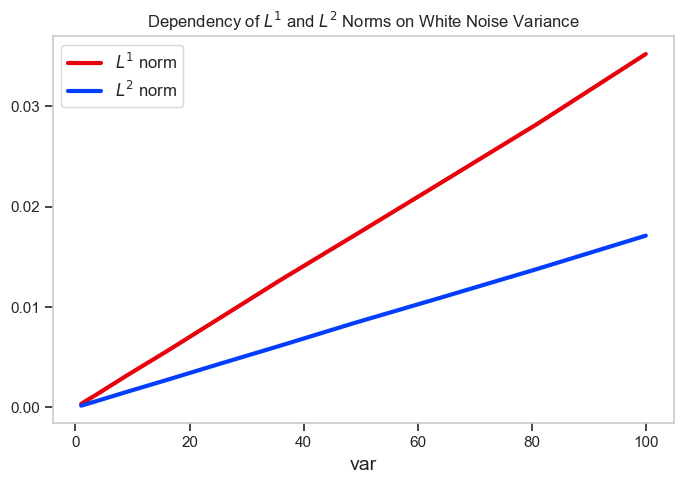

In [3]:
variances = sigma_range ** 2

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(variances, p1_norms, color=colors[3], linewidth=3, label='$L^1$ norm')
ax.plot(variances, p2_norms, color=colors[0], linewidth=3, label='$L^2$ norm')

ax.set_xlabel('var', fontsize=14)
ax.yaxis.set_major_locator(MultipleLocator(0.01))
ax.tick_params(bottom=True, left=True, length=6, width=1.2)
ax.set_title(r'Dependency of $L^1$ and $L^2$ Norms on White Noise Variance', fontsize=12)
ax.legend(fontsize=12, loc='upper left')

plt.tight_layout()
plt.show()

The results match the paper exactly. We observe that both $L^1$ and $L^2$ norms increase linearly as variance increases.

## **Relationship between PL Norms and System State (Section 3.4)**

For the second benchmark, we analyse the effect of system state transitioning from *cool* to *heated* on PL norms. Theoretically, the increased variance of data points should increase the magnitude of PL norms *(similarly to previous experiment)*. This would suggest that a system transition is detectable geometrically by plotting the changes in PL norms.

To reproduce the experiment, we use the following parameters:
* ...

In [4]:
realizations = 100
steps = 100
gm_data = generate_gamma_transition_dataset(num_realizations=realizations, seed=random_seed)

# ASSUMPTION / PROXY
gm_t_interval = np.linspace(0, 5.0, 1000)

p1_matrix = np.zeros((realizations, steps))
p2_matrix = np.zeros((realizations, steps))
var_matrix = np.zeros((realizations, steps))

for r in range(realizations):
    for s in range(steps):
        arr = gm_data[r][s]
        p1, p2 = window_landscape_norms(arr, gm_t_interval)
        p1_matrix[r, s] = p1
        p2_matrix[r, s] = p2
        var_matrix[r, s] = np.mean(np.var(arr, axis=0))

p1_mean = np.mean(p1_matrix, axis=0)
p2_mean = np.mean(p2_matrix, axis=0)
avg_variance = np.mean(var_matrix, axis=0)

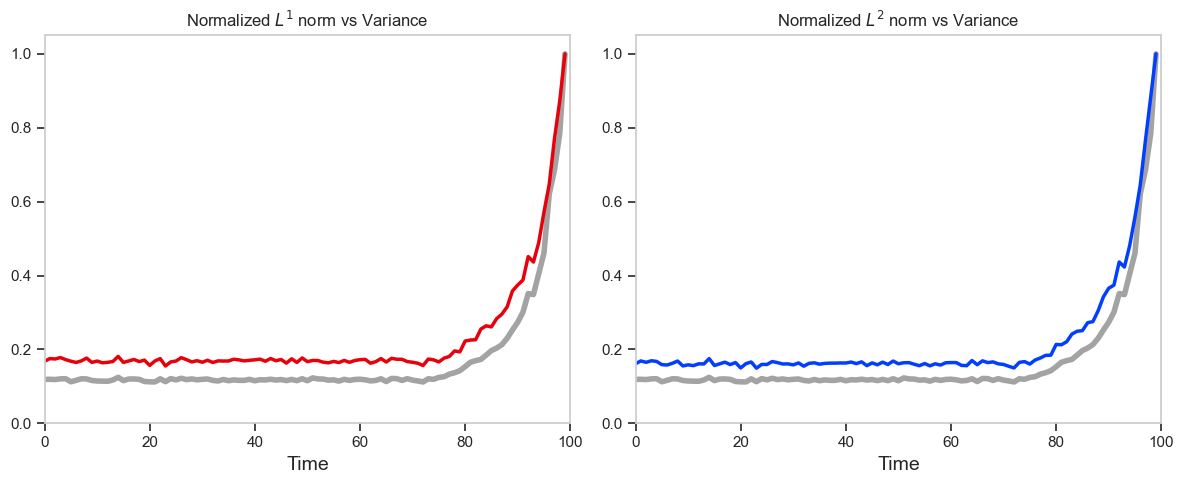

In [5]:
p1_normalized = p1_mean / np.max(p1_mean)
p2_normalized = p2_mean / np.max(p2_mean)
var_normalized = avg_variance / np.max(avg_variance)

time_steps = np.arange(0, steps)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(time_steps, var_normalized, color=colors[7], linewidth=4.0, zorder=1, label='Average variance')
ax1.plot(time_steps, p1_normalized, color=colors[3], linewidth=2.5, zorder=2, label='Normalized $L^1$-norm')
ax1.set_xlabel('Time', fontsize=14)
ax1.set_xlim(0, 100)
ax1.set_ylim(0.0, 1.05)
ax1.yaxis.set_major_locator(MultipleLocator(0.2))
ax1.tick_params(bottom=True, left=True, length=6, width=1.2)
ax1.set_title(r'Normalized $L^1$ norm vs Variance', fontsize=12)

ax2.plot(time_steps, var_normalized, color=colors[7], linewidth=4.0, zorder=1, label='Average variance')
ax2.plot(time_steps, p2_normalized, color=colors[0], linewidth=2.5, zorder=2, label='Normalized $L^2$-norm')
ax2.set_xlabel('Time', fontsize=14)
ax2.set_xlim(0, 100)
ax2.set_ylim(0.0, 1.05)
ax2.yaxis.set_major_locator(MultipleLocator(0.2))
ax2.tick_params(bottom=True, left=True, length=6, width=1.2)
ax2.set_title(r'Normalized $L^2$ norm vs Variance', fontsize=12)

plt.tight_layout()
plt.show()

The results once again match the paper exactly. We see consistently low $L^1$ and $L^2$ norms up until $t = 75$, after which the norms, as well as variance of the underlying point clouds, shoot up exponentially.

## **Using PL Norms to Analyse Financial Time Series Data (Section 4)**

For the main part of the paper, we use the same approach of computing PL norms on financial time series data to investigate the changing geometry before market crashes. We begin by importing ...

In [2]:
data = yf.download(
    ['^GSPC', '^DJI', '^IXIC', '^RUT'], start='1987-12-23', end='2016-12-09', progress=False
)

df_close = data['Close']

df = df_close.rename(
    columns={
        '^DJI': 'DJIA',
        '^GSPC': 'SP500',
        '^IXIC': 'NASDAQ',
        '^RUT': 'RUSSELL2000',
    }
)

print(df.head(3))
print(f"\n{df.count()}")

Ticker      DJIA       SP500      NASDAQ  RUSSELL2000
Date                                                 
1987-12-23   NaN  253.160004  331.500000   120.800003
1987-12-24   NaN  252.029999  333.200012   121.589996
1987-12-28   NaN  245.570007  325.600006   119.000000

Ticker
DJIA           6284
SP500          7301
NASDAQ         7301
RUSSELL2000    7301
dtype: int64


Note that part of DJIA data is no longer accessible via `yfinance` library (precisely all data until 1992). As these dates are inconsequential for the reproduction, we will drop all dates before January 1st, 1992 to resolve this issue.

We proceed with computing log returns and investigating the change in PL norms before the 2000 dotcom crash.  

In [21]:
returns_df = np.log(df / df.shift(1)).dropna()

returns = returns_df.values
dates = returns_df.index

window_size = [50, 100]
rows = returns.shape[0]

# ASSUMPTION / PROXY
t_interval = np.linspace(0, 0.1, 1000)

p1_50days = np.zeros(rows - 50)
p2_50days = np.zeros(rows - 50)
p1_100days = np.zeros(rows - 100)
p2_100days = np.zeros(rows - 100)

for w in window_size:
    for i in range(rows - w):
        arr = returns[i:(i+w), :]
        p1, p2 = window_landscape_norms(arr, t_interval, scaled=False, num_layers=3)

        if w == 50:
            p1_50days[i] = p1
            p2_50days[i] = p2
        if w == 100:
            p1_100days[i] = p1
            p2_100days[i] = p2

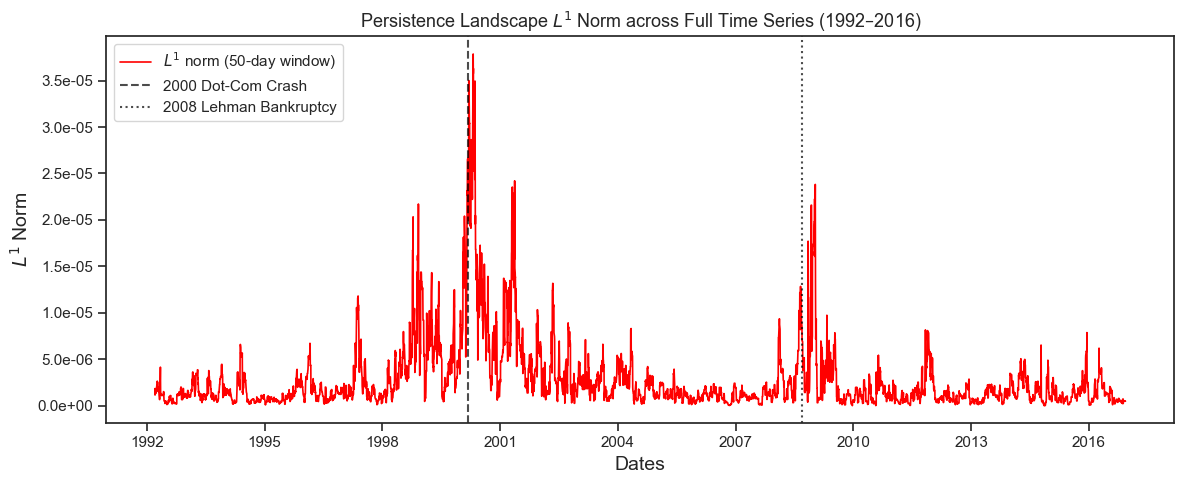

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))

# 1. Plot full time series of L1 norm (50-day window)
ax.plot(
    dates[50:],
    p1_50days,
    color='red',
    linewidth=1.2,
    label='$L^1$ norm (50-day window)',
)

# 2. Add vertical dashed lines for historical crash dates
ax.axvline(
    x=pd.Timestamp('2000-03-10'),
    color='black',
    linestyle='--',
    linewidth=1.5,
    alpha=0.7,
    label='2000 Dot-Com Crash',
)
ax.axvline(
    x=pd.Timestamp('2008-09-15'),
    color='black',
    linestyle=':',
    linewidth=1.5,
    alpha=0.7,
    label='2008 Lehman Bankruptcy',
)

# 3. Axis styling and labels
ax.set_xlabel('Dates', fontsize=14)
ax.set_ylabel('$L^1$ Norm', fontsize=14)
ax.tick_params(bottom=True, left=True, length=6, width=1.2)
ax.set_title(
    'Persistence Landscape $L^1$ Norm across Full Time Series (1992–2016)',
    fontsize=13,
)

# 4. Format date and y-axis ticks
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1e'))
ax.xaxis.set_major_locator(mdates.YearLocator(3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

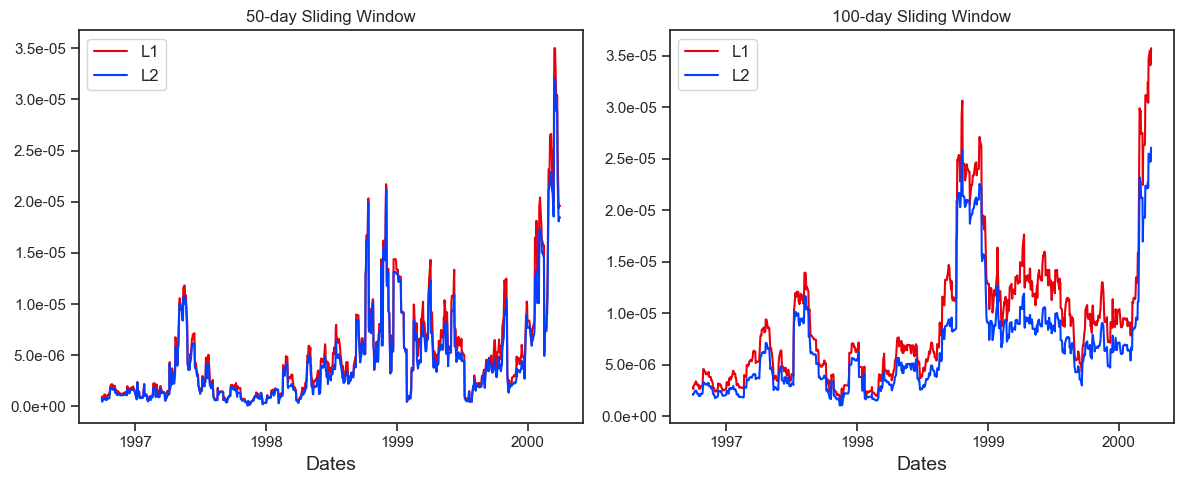

In [24]:
dates_50 = dates[50:]
mask_50 = (dates_50 >= '1996-10-01') & (dates_50 <= '2000-04-01')

sub_dates_50 = dates_50[mask_50]
sub_p1_50 = p1_50days[mask_50]
sub_p2_50 = p2_50days[mask_50]

dates_100 = dates[100:]
mask_100 = (dates_100 >= '1996-10-01') & (dates_100 <= '2000-04-01')

sub_dates_100 = dates_100[mask_100]
sub_p1_100 = p1_100days[mask_100]
sub_p2_100 = p2_100days[mask_100]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: w = 50 days
ax1.plot(sub_dates_50, sub_p1_50, color=colors[3], linewidth=1.5, label='L1')
ax1.plot(sub_dates_50, sub_p2_50, color=colors[0], linewidth=1.5, label='L2')
ax1.set_xlabel('Dates', fontsize=14)
ax1.tick_params(bottom=True, left=True, length=6, width=1.2)
ax1.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1e'))
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.set_title('50-day Sliding Window', fontsize=12)
ax1.legend(fontsize=12, loc='upper left')

# Right: w = 100 days
ax2.plot(sub_dates_100, sub_p1_100, color=colors[3], linewidth=1.5, label='L1')
ax2.plot(sub_dates_100, sub_p2_100, color=colors[0], linewidth=1.5, label='L2')
ax2.set_xlabel('Dates', fontsize=14)
ax2.tick_params(bottom=True, left=True, length=6, width=1.2)
ax2.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1e'))
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.set_title('100-day Sliding Window', fontsize=12)
ax2.legend(fontsize=12, loc='upper left')

plt.tight_layout()
plt.show()

Our figure is consistent with the paper. We see that both norms shoot up right before the crash and are generally moving in the same directions. There is a slightly higher discrepancy between $L^1$ and $L^2$ norms using a $w = 100$ time window, but the overall trend does not change.

In [18]:
def min_max_scale(x):
    return (x - np.min(x)) / (np.max(x) - np.min(x))

def get_1000_days_prior(plot_dates, crash_date_str):
    idx_crash = plot_dates.get_indexer(
        [pd.Timestamp(crash_date_str)], method='nearest'
    )[0]
    return slice(max(0, idx_crash - 1000), idx_crash + 1)

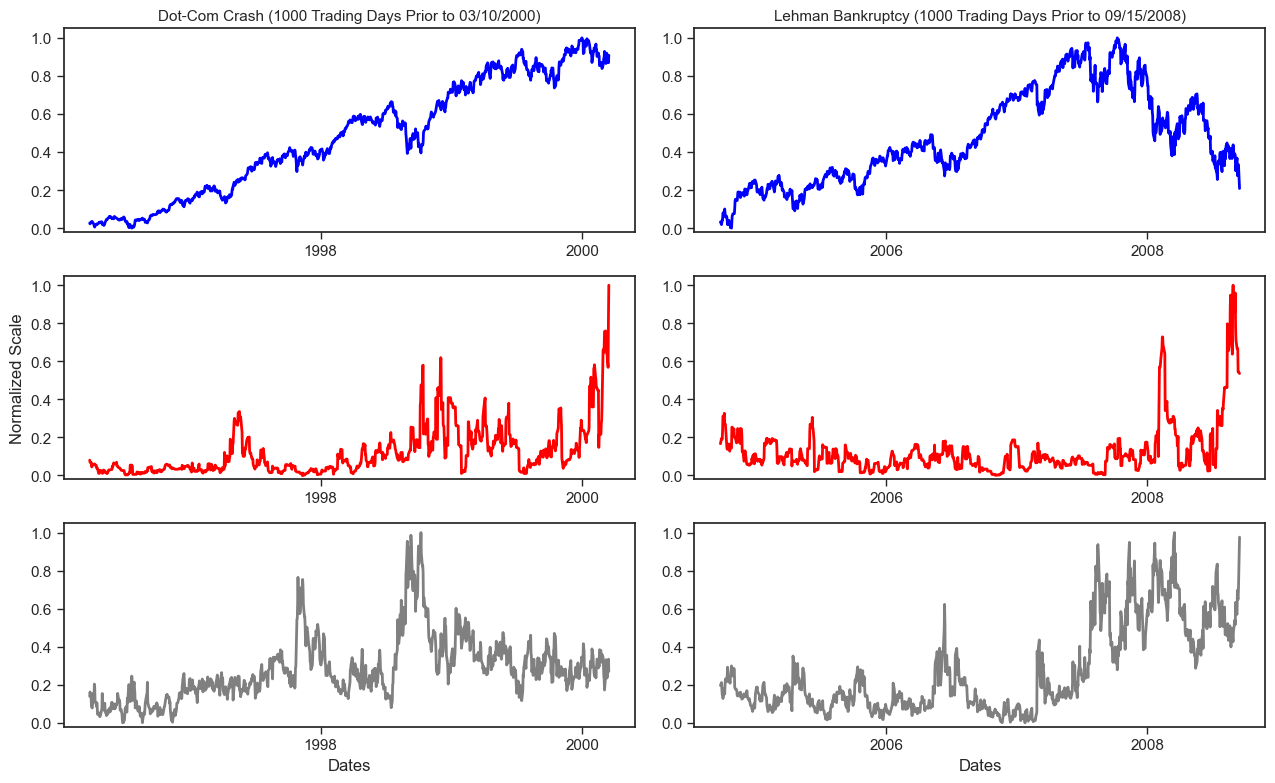

In [25]:
vix = yf.download('^VIX', start='1992-01-01', end='2016-12-09', progress=False)['Close']
vix_series = vix.iloc[:, 0]

sp500_price = df['SP500']

plot_dates = dates[50:]
sp500_aligned = sp500_price.loc[plot_dates]
vix_aligned = vix_series.loc[plot_dates]

mask_dotcom = get_1000_days_prior(plot_dates, '2000-03-15')
mask_lehman = get_1000_days_prior(plot_dates, '2008-09-15')

fig, axes = plt.subplots(3, 2, figsize=(13, 8), sharey=False)

dates_dotcom = plot_dates[mask_dotcom]

axes[0, 0].plot(
    dates_dotcom,
    min_max_scale(sp500_aligned[mask_dotcom]),
    color='blue',
    linewidth=2,
)
axes[0, 0].set_title(
    "Dot-Com Crash (1000 Trading Days Prior to 03/10/2000)", fontsize=11
)

axes[1, 0].plot(
    dates_dotcom,
    min_max_scale(p1_50days[mask_dotcom]),
    color='red',
    linewidth=2,
)
axes[1, 0].set_ylabel('Normalized Scale', fontsize=12)

axes[2, 0].plot(
    dates_dotcom,
    min_max_scale(vix_aligned[mask_dotcom]),
    color='gray',
    linewidth=2,
)
axes[2, 0].set_xlabel('Dates', fontsize=12)

dates_lehman = plot_dates[mask_lehman]

axes[0, 1].plot(
    dates_lehman,
    min_max_scale(sp500_aligned[mask_lehman]),
    color='blue',
    linewidth=2,
)
axes[0, 1].set_title(
    "Lehman Bankruptcy (1000 Trading Days Prior to 09/15/2008)", fontsize=11
)

axes[1, 1].plot(
    dates_lehman,
    min_max_scale(p1_50days[mask_lehman]),
    color='red',
    linewidth=2,
)

axes[2, 1].plot(
    dates_lehman,
    min_max_scale(vix_aligned[mask_lehman]),
    color='gray',
    linewidth=2,
)
axes[2, 1].set_xlabel('Dates', fontsize=12)

for ax in axes.flat:
    ax.tick_params(bottom=True, left=True, length=5, width=1.0)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_ylim(-0.02, 1.05)

plt.tight_layout()
plt.show()

For this graph, we had to move the start date of dotcom crash 5 days into the future (from March 10 to March 15). Otherwise, The peaks right before 1999 would overshadow the peak right before the crash. Although the trends match those found in the paper (norms increase before crashes), this does signal a potential limitation of applying TDA in real time. That is, if a signal only gets very strong after the crash, the method loses its usefulness.

Nonetheless, ... (discuss the graphs and how the trends correctly indicate crashes even if variation is actually quite low, 2-3 sentences max).

#### **Early Warning Signal Analysis**

The final section of the paper conducts EWS analysis to determine whether we can use this approach to detect critical slowing down (CSD) of a dynamic system (stock market). For this purpose, we use three main measures, which should increase before a crash.
* Variance: reduced resilience allows market shocks to cause wider price swings.
* Average Spectral Density at Low Frequencies: fluctuation energy shifts toward longer-period waves ("spectral reddening").
* First Lag of the Autocorrelation Function (ACF(1)): slower recovery creates longer memory of past shocks.



Dot‑Com Crash (2000‑03‑10):
L1 Variance           τ = -0.1996  (p = 0.0000)
L2 Variance           τ = -0.3306  (p = 0.0000)
L1 Spectrum           τ = +0.9226  (p = 0.0000)
L2 Spectrum           τ = +0.8788  (p = 0.0000)
L1 ACF(1)             τ = -0.7004  (p = 0.0000)
L2 ACF(1)             τ = -0.7258  (p = 0.0000)
VIX Variance          τ = -0.8346  (p = 0.0000)
VIX Spectrum          τ = -0.5339  (p = 0.0000)
VIX ACF(1)            τ = -0.8742  (p = 0.0000)

Lehman Bankruptcy (2008‑09‑15):
L1 Variance           τ = +0.8981  (p = 0.0000)
L2 Variance           τ = +0.9566  (p = 0.0000)
L1 Spectrum           τ = +0.7860  (p = 0.0000)
L2 Spectrum           τ = +0.7950  (p = 0.0000)
L1 ACF(1)             τ = +0.4124  (p = 0.0000)
L2 ACF(1)             τ = +0.4034  (p = 0.0000)
VIX Variance          τ = +0.8515  (p = 0.0000)
VIX Spectrum          τ = +0.6452  (p = 0.0000)
VIX ACF(1)            τ = +0.7573  (p = 0.0000)


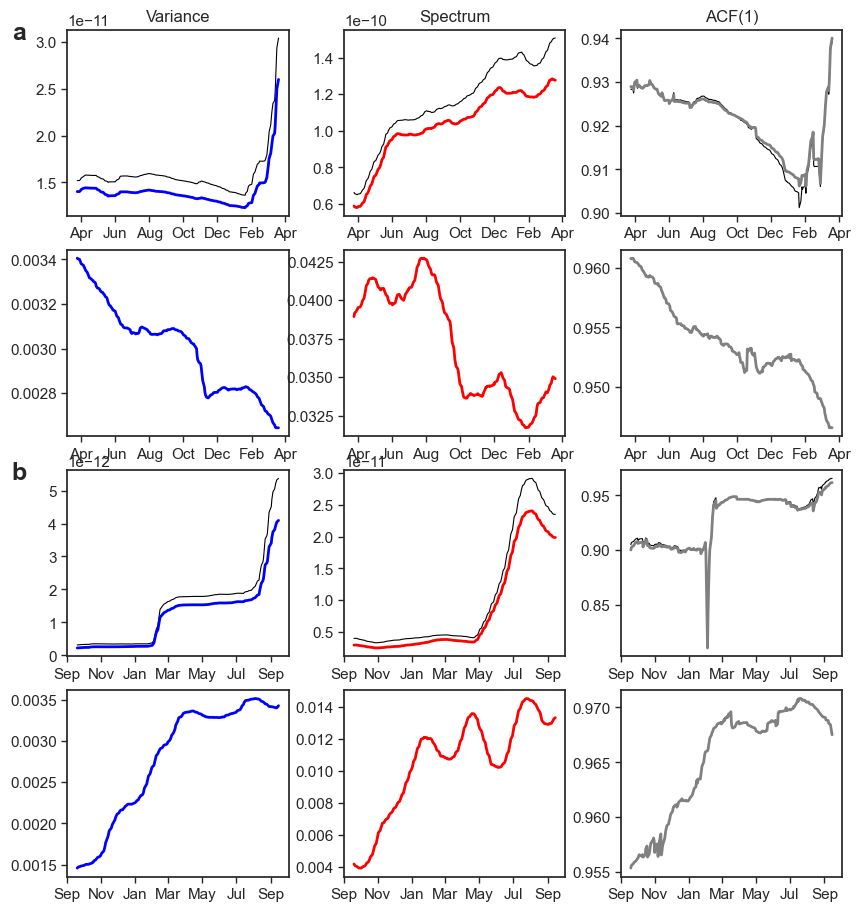

In [ ]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.signal import welch
from scipy.stats import kendalltau

sns.set_theme(style='white', rc={'axes.grid': False})
plt.rcParams['axes.grid'] = False

vix_series = (
    vix.reindex(dates_50).ffill().bfill()
    if not isinstance(vix, pd.Series)
    else vix.reindex(dates_50).ffill().bfill()
)
vix_vals = (
    vix_series.iloc[:, 0].values
    if isinstance(vix_series, pd.DataFrame)
    else vix_series.values
)
vix_scaled = vix_vals / 100.0

def compute_indicators_raw(series, dates, crash_date_str,
                           stat_window=500, eval_days=250):
    """
    Computes Variance, Spectrum, and ACF(1) on RAW 500-day windows.
    Spectrum: Welch, avg over frequencies ≤ 10% of Nyquist.
    """
    idx_crash = dates.get_indexer([pd.Timestamp(crash_date_str)], method='nearest')[0]
    eval_indices = range(idx_crash - eval_days + 1, idx_crash + 1)
    eval_dates = dates[eval_indices]

    variances, acfs, specs = [], [], []

    for idx in eval_indices:
        win = series[max(0, idx - stat_window + 1) : idx + 1]

        # 1. Variance (raw)
        variances.append(np.var(win))

        # 2. ACF(1) (raw)
        acfs.append(pd.Series(win).autocorr(lag=1))

        # 3. Spectrum (Welch, relative cutoff 10%)
        freqs, psd = welch(win, nperseg=min(128, len(win)))
        mask = freqs <= (0.1 * np.max(freqs))
        specs.append(np.mean(psd[mask]))

    return (eval_dates,
            np.array(variances),
            np.array(acfs),
            np.array(specs))

d_a, v1_a, acf1_a, spec1_a = compute_indicators_raw(p1_50days, dates_50, '2000-03-10')
_,   v2_a, acf2_a, spec2_a = compute_indicators_raw(p2_50days, dates_50, '2000-03-10')
_,   vix_v_a, vix_acf_a, vix_spec_a = compute_indicators_raw(vix_scaled, dates_50, '2000-03-10')

d_b, v1_b, acf1_b, spec1_b = compute_indicators_raw(p1_50days, dates_50, '2008-09-15')
_,   v2_b, acf2_b, spec2_b = compute_indicators_raw(p2_50days, dates_50, '2008-09-15')
_,   vix_v_b, vix_acf_b, vix_spec_b = compute_indicators_raw(vix_scaled, dates_50, '2008-09-15')

def kendall_report(name, vals):
    tau, p = kendalltau(np.arange(len(vals)), vals)
    print(f"{name:20s}  τ = {tau:+.4f}  (p = {p:.4f})")

print("Dot‑Com Crash (2000‑03‑10):")
for name, vals in [('L1 Variance', v1_a), ('L2 Variance', v2_a),
                   ('L1 Spectrum', spec1_a), ('L2 Spectrum', spec2_a),
                   ('L1 ACF(1)', acf1_a), ('L2 ACF(1)', acf2_a),
                   ('VIX Variance', vix_v_a), ('VIX Spectrum', vix_spec_a),
                   ('VIX ACF(1)', vix_acf_a)]:
    kendall_report(name, vals)

print("\nLehman Bankruptcy (2008‑09‑15):")
for name, vals in [('L1 Variance', v1_b), ('L2 Variance', v2_b),
                   ('L1 Spectrum', spec1_b), ('L2 Spectrum', spec2_b),
                   ('L1 ACF(1)', acf1_b), ('L2 ACF(1)', acf2_b),
                   ('VIX Variance', vix_v_b), ('VIX Spectrum', vix_spec_b),
                   ('VIX ACF(1)', vix_acf_b)]:
    kendall_report(name, vals)

fig = plt.figure(figsize=(10, 11))
gs = fig.add_gridspec(4, 3, hspace=0.18, wspace=0.25)

ax_a_v_land = fig.add_subplot(gs[0, 0]); ax_a_s_land = fig.add_subplot(gs[0, 1]); ax_a_a_land = fig.add_subplot(gs[0, 2])
ax_a_v_vix = fig.add_subplot(gs[1, 0]); ax_a_s_vix = fig.add_subplot(gs[1, 1]); ax_a_a_vix = fig.add_subplot(gs[1, 2])
ax_b_v_land = fig.add_subplot(gs[2, 0]); ax_b_s_land = fig.add_subplot(gs[2, 1]); ax_b_a_land = fig.add_subplot(gs[2, 2])
ax_b_v_vix = fig.add_subplot(gs[3, 0]); ax_b_s_vix = fig.add_subplot(gs[3, 1]); ax_b_a_vix = fig.add_subplot(gs[3, 2])

# Dot-Com Landscapes
ax_a_v_land.plot(d_a, v1_a, 'black', lw=0.8); ax_a_v_land.plot(d_a, v2_a, 'blue', lw=2.0)
ax_a_v_land.set_title('Variance'); ax_a_v_land.text(-0.25,0.95,'a',transform=ax_a_v_land.transAxes,fontsize=18,fontweight='bold')
ax_a_s_land.plot(d_a, spec1_a, 'black', lw=0.8); ax_a_s_land.plot(d_a, spec2_a, 'red', lw=2.0)
ax_a_s_land.set_title('Spectrum')
ax_a_a_land.plot(d_a, acf1_a, 'black', lw=0.8); ax_a_a_land.plot(d_a, acf2_a, 'gray', lw=2.0)
ax_a_a_land.set_title('ACF(1)')

# Dot-Com VIX
ax_a_v_vix.plot(d_a, vix_v_a, 'blue', lw=2.0)
ax_a_s_vix.plot(d_a, vix_spec_a, 'red', lw=2.0)
ax_a_a_vix.plot(d_a, vix_acf_a, 'gray', lw=2.0)

# Lehman Landscapes
ax_b_v_land.plot(d_b, v1_b, 'black', lw=0.8); ax_b_v_land.plot(d_b, v2_b, 'blue', lw=2.0)
ax_b_v_land.text(-0.25,0.95,'b',transform=ax_b_v_land.transAxes,fontsize=18,fontweight='bold')
ax_b_s_land.plot(d_b, spec1_b, 'black', lw=0.8); ax_b_s_land.plot(d_b, spec2_b, 'red', lw=2.0)
ax_b_a_land.plot(d_b, acf1_b, 'black', lw=0.8); ax_b_a_land.plot(d_b, acf2_b, 'gray', lw=2.0)

# Lehman VIX
ax_b_v_vix.plot(d_b, vix_v_b, 'blue', lw=2.0)
ax_b_s_vix.plot(d_b, vix_spec_b, 'red', lw=2.0)
ax_b_a_vix.plot(d_b, vix_acf_b, 'gray', lw=2.0)

for ax in fig.axes:
    ax.tick_params(bottom=True, left=True, length=4, width=1.0)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.show()

Dot‑Com Crash (2000‑03‑10):
L1 Variance           τ = +0.6830  (p = 0.0000)
L2 Variance           τ = +0.6643  (p = 0.0000)
L1 Spectrum           τ = +0.8681  (p = 0.0000)
L2 Spectrum           τ = +0.8431  (p = 0.0000)
L1 ACF(1)             τ = +0.0966  (p = 0.0229)
L2 ACF(1)             τ = +0.1568  (p = 0.0002)
VIX Variance          τ = -0.8347  (p = 0.0000)
VIX Spectrum          τ = -0.5279  (p = 0.0000)
VIX ACF(1)            τ = -0.8743  (p = 0.0000)

Lehman Bankruptcy (2008‑09‑15):
L1 Variance           τ = +0.8153  (p = 0.0000)
L2 Variance           τ = +0.9177  (p = 0.0000)
L1 Spectrum           τ = +0.8453  (p = 0.0000)
L2 Spectrum           τ = +0.8465  (p = 0.0000)
L1 ACF(1)             τ = +0.2556  (p = 0.0000)
L2 ACF(1)             τ = +0.2483  (p = 0.0000)
VIX Variance          τ = +0.8515  (p = 0.0000)
VIX Spectrum          τ = +0.6452  (p = 0.0000)
VIX ACF(1)            τ = +0.7573  (p = 0.0000)
L1 dotcom    max|var-spec| = 1.2982e-10, Pearson r = 0.5505
L2 dotcom    ma

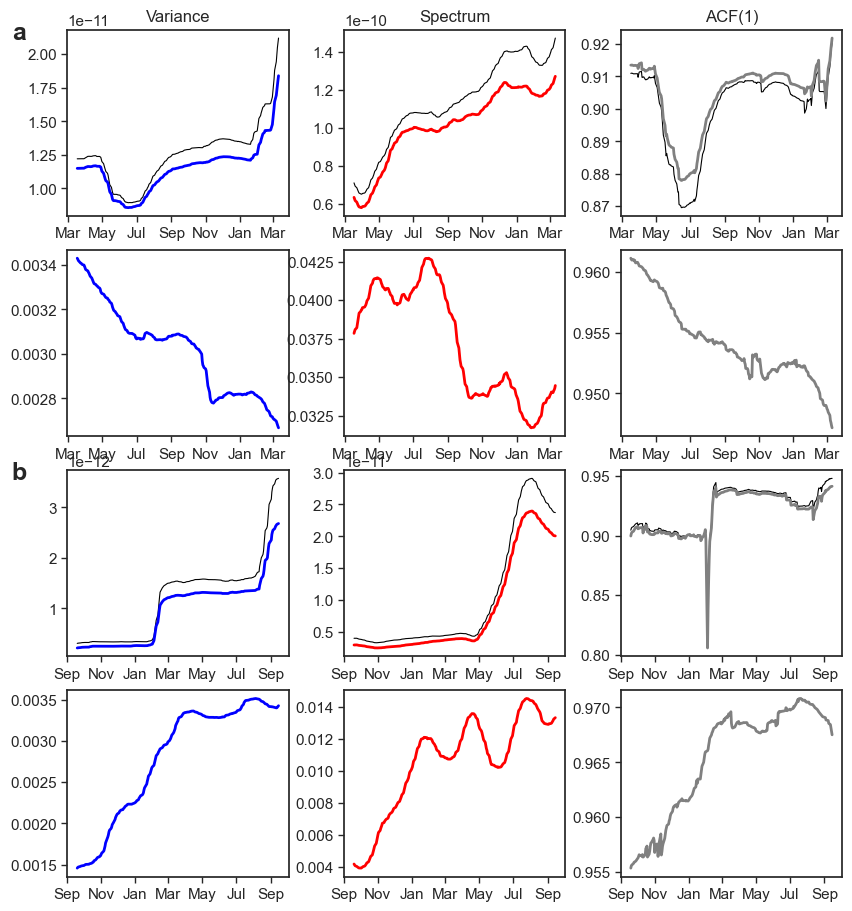

In [ ]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.signal import detrend, welch
from scipy.stats import kendalltau

sns.set_theme(style='white', rc={'axes.grid': False})
plt.rcParams['axes.grid'] = False

vix_series = (
    vix.reindex(dates_50).ffill().bfill()
    if not isinstance(vix, pd.Series)
    else vix.reindex(dates_50).ffill().bfill()
)
vix_vals = (
    vix_series.iloc[:, 0].values
    if isinstance(vix_series, pd.DataFrame)
    else vix_series.values
)
vix_scaled = vix_vals / 100.0

def compute_indicators(series, dates, crash_date_str,
                       stat_window=500, eval_days=250,
                       detrend_win=False):
    """
    detrend_win=True  → linear detrend inside each 500‑day window (for landscape norms)
    detrend_win=False → raw window (for VIX)
    Spectrum: Welch, averaged over frequencies ≤ 10% of Nyquist.
    """
    idx_crash = dates.get_indexer([pd.Timestamp(crash_date_str)], method='nearest')[0]
    eval_indices = range(idx_crash - eval_days + 1, idx_crash + 1)
    eval_dates = dates[eval_indices]

    variances, acfs, specs = [], [], []

    for idx in eval_indices:
        win = series[max(0, idx - stat_window + 1) : idx + 1]

        if detrend_win:
            win_proc = detrend(win, type='linear')
        else:
            win_proc = win

        # 1. Variance
        variances.append(np.var(win_proc))

        # 2. ACF(1)
        acfs.append(pd.Series(win_proc).autocorr(lag=1))

        # 3. Spectrum (Welch, relative cutoff 10%)
        freqs, psd = welch(win_proc, nperseg=min(128, len(win_proc)))
        mask = freqs <= (0.1 * np.max(freqs))
        specs.append(np.mean(psd[mask]))

    return (eval_dates,
            np.array(variances),
            np.array(acfs),
            np.array(specs))

d_a, v1_a, acf1_a, spec1_a = compute_indicators(p1_50days, dates_50, '2000-03-10', detrend_win=True)
_,   v2_a, acf2_a, spec2_a = compute_indicators(p2_50days, dates_50, '2000-03-10', detrend_win=True)
_,   vix_v_a, vix_acf_a, vix_spec_a = compute_indicators(vix_scaled, dates_50, '2000-03-10', detrend_win=False)

d_b, v1_b, acf1_b, spec1_b = compute_indicators(p1_50days, dates_50, '2008-09-15', detrend_win=True)
_,   v2_b, acf2_b, spec2_b = compute_indicators(p2_50days, dates_50, '2008-09-15', detrend_win=True)
_,   vix_v_b, vix_acf_b, vix_spec_b = compute_indicators(vix_scaled, dates_50, '2008-09-15', detrend_win=False)

def kendall_report(name, vals):
    tau, p = kendalltau(np.arange(len(vals)), vals)
    print(f"{name:20s}  τ = {tau:+.4f}  (p = {p:.4f})")

print("Dot‑Com Crash (2000‑03‑10):")
for name, vals in [('L1 Variance', v1_a), ('L2 Variance', v2_a),
                   ('L1 Spectrum', spec1_a), ('L2 Spectrum', spec2_a),
                   ('L1 ACF(1)', acf1_a), ('L2 ACF(1)', acf2_a),
                   ('VIX Variance', vix_v_a), ('VIX Spectrum', vix_spec_a),
                   ('VIX ACF(1)', vix_acf_a)]:
    kendall_report(name, vals)

print("\nLehman Bankruptcy (2008‑09‑15):")
for name, vals in [('L1 Variance', v1_b), ('L2 Variance', v2_b),
                   ('L1 Spectrum', spec1_b), ('L2 Spectrum', spec2_b),
                   ('L1 ACF(1)', acf1_b), ('L2 ACF(1)', acf2_b),
                   ('VIX Variance', vix_v_b), ('VIX Spectrum', vix_spec_b),
                   ('VIX ACF(1)', vix_acf_b)]:
    kendall_report(name, vals)

for label, var, spec in [('L1 dotcom', v1_a, spec1_a),
                         ('L2 dotcom', v2_a, spec2_a),
                         ('VIX dotcom', vix_v_a, vix_spec_a)]:
    print(f"{label:12s} max|var-spec| = {np.max(np.abs(var - spec)):.4e}, "
          f"Pearson r = {np.corrcoef(var, spec)[0,1]:.4f}")

fig = plt.figure(figsize=(10, 11))
gs = fig.add_gridspec(4, 3, hspace=0.18, wspace=0.25)

ax_a_v_land = fig.add_subplot(gs[0, 0]); ax_a_s_land = fig.add_subplot(gs[0, 1]); ax_a_a_land = fig.add_subplot(gs[0, 2])
ax_a_v_vix = fig.add_subplot(gs[1, 0]); ax_a_s_vix = fig.add_subplot(gs[1, 1]); ax_a_a_vix = fig.add_subplot(gs[1, 2])
ax_b_v_land = fig.add_subplot(gs[2, 0]); ax_b_s_land = fig.add_subplot(gs[2, 1]); ax_b_a_land = fig.add_subplot(gs[2, 2])
ax_b_v_vix = fig.add_subplot(gs[3, 0]); ax_b_s_vix = fig.add_subplot(gs[3, 1]); ax_b_a_vix = fig.add_subplot(gs[3, 2])

ax_a_v_land.plot(d_a, v1_a, 'black', lw=0.8); ax_a_v_land.plot(d_a, v2_a, 'blue', lw=2.0)
ax_a_v_land.set_title('Variance'); ax_a_v_land.text(-0.25,0.95,'a',transform=ax_a_v_land.transAxes,fontsize=18,fontweight='bold')
ax_a_s_land.plot(d_a, spec1_a, 'black', lw=0.8); ax_a_s_land.plot(d_a, spec2_a, 'red', lw=2.0)
ax_a_s_land.set_title('Spectrum')
ax_a_a_land.plot(d_a, acf1_a, 'black', lw=0.8); ax_a_a_land.plot(d_a, acf2_a, 'gray', lw=2.0)
ax_a_a_land.set_title('ACF(1)')

ax_a_v_vix.plot(d_a, vix_v_a, 'blue', lw=2.0)
ax_a_s_vix.plot(d_a, vix_spec_a, 'red', lw=2.0)
ax_a_a_vix.plot(d_a, vix_acf_a, 'gray', lw=2.0)

ax_b_v_land.plot(d_b, v1_b, 'black', lw=0.8); ax_b_v_land.plot(d_b, v2_b, 'blue', lw=2.0)
ax_b_v_land.text(-0.25,0.95,'b',transform=ax_b_v_land.transAxes,fontsize=18,fontweight='bold')
ax_b_s_land.plot(d_b, spec1_b, 'black', lw=0.8); ax_b_s_land.plot(d_b, spec2_b, 'red', lw=2.0)
ax_b_a_land.plot(d_b, acf1_b, 'black', lw=0.8); ax_b_a_land.plot(d_b, acf2_b, 'gray', lw=2.0)

ax_b_v_vix.plot(d_b, vix_v_b, 'blue', lw=2.0)
ax_b_s_vix.plot(d_b, vix_spec_b, 'red', lw=2.0)
ax_b_a_vix.plot(d_b, vix_acf_b, 'gray', lw=2.0)

for ax in fig.axes:
    ax.tick_params(bottom=True, left=True, length=4, width=1.0)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

plt.show()

In [67]:
# from scipy.signal import detrend, welch
# import pandas as pd
# import numpy as np

# def compute_rolling_indicators(
#     series,
#     plot_dates,
#     crash_date_str,
#     stat_window=500,
#     eval_days=250,
#     detrend_mode='linear',
# ):
#     idx_crash = plot_dates.get_indexer(
#         [pd.Timestamp(crash_date_str)], method='nearest'
#     )[0]
#     eval_indices = range(idx_crash - eval_days + 1, idx_crash + 1)
#     eval_dates = plot_dates[eval_indices]

#     variances, acfs, spectral_densities = [], [], []

#     for idx in eval_indices:
#         win = series[max(0, idx - stat_window + 1) : idx + 1]

#         if detrend_mode == 'linear':
#             win_proc = detrend(win, type='linear')
#         else:
#             win_proc = win

#         # 1. Variance
#         variances.append(np.var(win_proc))

#         # 2. ACF (Computed on win_proc to produce the spiky, highly variant curve)
#         s_win = pd.Series(win_proc)
#         acfs.append(s_win.autocorr(lag=1))

#         # 3. Spectrum (Welch)
#         freqs, psd = welch(win_proc, nperseg=min(128, len(win_proc)))
#         low_freq_mask = freqs <= (0.1 * np.max(freqs))
#         spectral_densities.append(np.mean(psd[low_freq_mask]))

#     return (
#         eval_dates,
#         np.array(variances),
#         np.array(acfs),
#         np.array(spectral_densities),
#     )

In [66]:
# from scipy.stats import kendalltau

# # Evaluate indicators 250 trading days prior to Dot-com Crash (03/10/2000)
# dates_dotcom, var_dotcom, acf_dotcom, spec_dotcom = compute_rolling_indicators(
#     p1_50days, dates_50, '2000-03-10'
# )

# # Evaluate indicators 250 trading days prior to Lehman Bankruptcy (09/15/2008)
# dates_lehman, var_lehman, acf_lehman, spec_lehman = compute_rolling_indicators(
#     p1_50days, dates_50, '2008-09-15'
# )

# # Mann-Kendall Trend Test (Kendall-tau rank correlation coefficient)
# tau_spec_dotcom, _ = kendalltau(range(len(spec_dotcom)), spec_dotcom)
# tau_spec_lehman, _ = kendalltau(range(len(spec_lehman)), spec_lehman)

# tau_var_dotcom, _ = kendalltau(range(len(var_dotcom)), var_dotcom)
# tau_var_lehman, _ = kendalltau(range(len(var_lehman)), var_lehman)

# tau_acf_dotcom, _ = kendalltau(range(len(acf_dotcom)), acf_dotcom)
# tau_acf_lehman, _ = kendalltau(range(len(acf_lehman)), acf_lehman)

# print(f"Dot-Com Crash (03/10/2000) Low-Freq Spectral Density Kendall-tau: {tau_spec_dotcom:.2f}")
# print(f"Lehman Bankruptcy (09/15/2008) Low-Freq Spectral Density Kendall-tau: {tau_spec_lehman:.2f}")

# print(f"Dot-Com Crash (03/10/2000) Low-Freq Spectral Density Kendall-tau: {tau_var_dotcom:.2f}")
# print(f"Lehman Bankruptcy (09/15/2008) Low-Freq Spectral Density Kendall-tau: {tau_var_lehman:.2f}")

# print(f"Dot-Com Crash (03/10/2000) Low-Freq Spectral Density Kendall-tau: {tau_acf_dotcom:.2f}")
# print(f"Lehman Bankruptcy (09/15/2008) Low-Freq Spectral Density Kendall-tau: {tau_acf_lehman:.2f}")

In [70]:
# import matplotlib.dates as mdates
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd
# import seaborn as sns
# from scipy.signal import periodogram

# # Ensure clean white theme without gridlines
# sns.set_theme(style='white', rc={'axes.grid': False})
# plt.rcParams['axes.grid'] = False

# # Align and scale VIX by 100
# vix_series = (
#     vix.reindex(dates_50).ffill().bfill()
#     if not isinstance(vix, pd.Series)
#     else vix.reindex(dates_50).ffill().bfill()
# )
# vix_vals = (
#     vix_series.iloc[:, 0].values
#     if isinstance(vix_series, pd.DataFrame)
#     else vix_series.values
# )
# vix_scaled = vix_vals / 100.0


# def compute_indicators(series, plot_dates, crash_date_str,
#                        stat_window=500, eval_days=250):
#     """
#     Compute the three early-warning indicators exactly as in Gidea & Katz (2018):
#       - Variance
#       - Average spectral density at low frequencies (periodogram, 0 < f ≤ 0.1)
#       - ACF at lag-1
#     No detrending is applied inside the rolling window.
#     """
#     idx_crash = plot_dates.get_indexer([pd.Timestamp(crash_date_str)], method='nearest')[0]
#     eval_indices = range(idx_crash - eval_days + 1, idx_crash + 1)
#     eval_dates = plot_dates[eval_indices]

#     variances, acfs, spectral_densities = [], [], []

#     for idx in eval_indices:
#         win = series[max(0, idx - stat_window + 1) : idx + 1]

#         # 1. Variance (raw)
#         variances.append(np.var(win))

#         # 2. ACF lag-1 (raw)
#         s_win = pd.Series(win)
#         acfs.append(s_win.autocorr(lag=1))

#         # 3. Spectrum (periodogram, low frequencies 0 < f ≤ 0.1)
#         win_demean = win - np.mean(win)
#         freqs, psd = periodogram(win_demean)
#         mask = (freqs > 0) & (freqs <= 0.1)
#         spectral_densities.append(np.mean(psd[mask]) if np.any(mask) else 0.0)

#     return (
#         eval_dates,
#         np.array(variances),
#         np.array(acfs),
#         np.array(spectral_densities),
#     )


# # --- Compute Indicators ---
# # Block (a): Dot-Com Crash (03/10/2000)
# d_a, v1_a, acf1_a, spec1_a = compute_indicators(p1_50days, dates_50, '2000-03-10')
# _, v2_a, acf2_a, spec2_a = compute_indicators(p2_50days, dates_50, '2000-03-10')
# _, v_vix_a, acf_vix_a, spec_vix_a = compute_indicators(vix_scaled, dates_50, '2000-03-10')

# # Block (b): Lehman Bankruptcy (09/15/2008)
# d_b, v1_b, acf1_b, spec1_b = compute_indicators(p1_50days, dates_50, '2008-09-15')
# _, v2_b, acf2_b, spec2_b = compute_indicators(p2_50days, dates_50, '2008-09-15')
# _, v_vix_b, acf_vix_b, spec_vix_b = compute_indicators(vix_scaled, dates_50, '2008-09-15')


# # --- Plotting (identical layout & colours as before) ---
# fig = plt.figure(figsize=(10, 11))
# gs = fig.add_gridspec(4, 3, hspace=0.18, wspace=0.25)

# ax_a_v_land = fig.add_subplot(gs[0, 0])
# ax_a_s_land = fig.add_subplot(gs[0, 1])
# ax_a_a_land = fig.add_subplot(gs[0, 2])
# ax_a_v_vix = fig.add_subplot(gs[1, 0])
# ax_a_s_vix = fig.add_subplot(gs[1, 1])
# ax_a_a_vix = fig.add_subplot(gs[1, 2])

# ax_b_v_land = fig.add_subplot(gs[2, 0])
# ax_b_s_land = fig.add_subplot(gs[2, 1])
# ax_b_a_land = fig.add_subplot(gs[2, 2])
# ax_b_v_vix = fig.add_subplot(gs[3, 0])
# ax_b_s_vix = fig.add_subplot(gs[3, 1])
# ax_b_a_vix = fig.add_subplot(gs[3, 2])

# # Row 0: Landscapes (Dot-Com)
# ax_a_v_land.plot(d_a, v1_a, color='black', linewidth=0.8)
# ax_a_v_land.plot(d_a, v2_a, color='blue', linewidth=2.0)
# ax_a_v_land.set_title('Variance', fontsize=11)
# ax_a_v_land.text(-0.25, 0.95, 'a', transform=ax_a_v_land.transAxes, fontsize=18, fontweight='bold')

# ax_a_s_land.plot(d_a, spec1_a, color='black', linewidth=0.8)
# ax_a_s_land.plot(d_a, spec2_a, color='red', linewidth=2.0)
# ax_a_s_land.set_title('Spectrum', fontsize=11)

# ax_a_a_land.plot(d_a, acf1_a, color='black', linewidth=0.8)
# ax_a_a_land.plot(d_a, acf2_a, color='gray', linewidth=2.0)
# ax_a_a_land.set_title('ACF(1)', fontsize=11)

# # Row 1: VIX (Dot-Com)
# ax_a_v_vix.plot(d_a, v_vix_a, color='blue', linewidth=2.0)
# ax_a_s_vix.plot(d_a, spec_vix_a, color='red', linewidth=2.0)
# ax_a_a_vix.plot(d_a, acf_vix_a, color='gray', linewidth=2.0)

# # Row 2: Landscapes (Lehman)
# ax_b_v_land.plot(d_b, v1_b, color='black', linewidth=0.8)
# ax_b_v_land.plot(d_b, v2_b, color='blue', linewidth=2.0)
# ax_b_v_land.text(-0.25, 0.95, 'b', transform=ax_b_v_land.transAxes, fontsize=18, fontweight='bold')

# ax_b_s_land.plot(d_b, spec1_b, color='black', linewidth=0.8)
# ax_b_s_land.plot(d_b, spec2_b, color='red', linewidth=2.0)

# ax_b_a_land.plot(d_b, acf1_b, color='black', linewidth=0.8)
# ax_b_a_land.plot(d_b, acf2_b, color='gray', linewidth=2.0)

# # Row 3: VIX (Lehman)
# ax_b_v_vix.plot(d_b, v_vix_b, color='blue', linewidth=2.0)
# ax_b_s_vix.plot(d_b, spec_vix_b, color='red', linewidth=2.0)
# ax_b_a_vix.plot(d_b, acf_vix_b, color='gray', linewidth=2.0)

# all_axes = [
#     ax_a_v_land, ax_a_s_land, ax_a_a_land,
#     ax_a_v_vix, ax_a_s_vix, ax_a_a_vix,
#     ax_b_v_land, ax_b_s_land, ax_b_a_land,
#     ax_b_v_vix, ax_b_s_vix, ax_b_a_vix
# ]

# for ax in all_axes:
#     ax.tick_params(bottom=True, left=True, length=4, width=1.0)
#     ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
#     ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# plt.show()